<a href="https://colab.research.google.com/github/minasaeday14/INFO-5731-spring-2026/blob/main/INFO5731_Assignment_2_(2026)_(1).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>



# **INFO5731 Assignment 2**

In this assignment, we will delve into various aspects of natural language processing (NLP) and text analysis. The tasks are designed to deepen your understanding of key NLP concepts and techniques, as well as to provide hands-on experience with practical applications.

Through these tasks, you'll gain practical experience in NLP techniques such as N-gram analysis, TF-IDF, word embedding model creation, and sentiment analysis dataset creation.

**Expectations**:
*   Use the provided .*ipynb* document to write your code & respond to the questions. Avoid generating a new file.
*   Write complete answers and run all the cells before submission.
*   Make sure the submission is "clean"; *i.e.*, no unnecessary code cells.
*   Once finished, allow shared rights from top right corner (*see Canvas for details*).


**Total points**: 100

**Deadline**: See Canvas

**Late Submission will have a penalty of 10% reduction for each day after the deadline.**


## Question 1 (25 points)

**Understand N-gram**

Write a python program to conduct N-gram analysis based on the dataset in your assignment two. You need to write codes from **scratch instead of using any pre-existing libraries** to do so:

(1) Count the frequency of all the N-grams (N=3) and (N=2).

(2) Calculate the probabilities for all the bigrams in the dataset by using the formula  count(w2 w1) / count(w2). For example, count(really like) / count(really) = 1 / 3 = 0.33.

(3) Extract all the noun phrases and calculate the relative
probabilities of each review in terms of other reviews (abstracts, or tweets) by using the formula  frequency (noun phrase) / max frequency (noun phrase) on the whole dataset.

Print out the result in a table with column name the all the noun phrases and row name as all the 100 reviews (abstracts, or tweets).

In [12]:
import re
import subprocess
import sys
from collections import Counter, defaultdict
from pathlib import Path

try:
    import pandas as pd
except ModuleNotFoundError:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "pandas"])
    import pandas as pd

try:
    from IPython.display import display
except ImportError:
    def display(obj):
        print(obj)

DATA_PATH = Path("q1_imdb_reviews_raw.csv")
TREE_PATH = Path("q3_constituency_trees.txt")
TARGET_REVIEW_COUNT = 100
NOUN_TAGS = {"NN", "NNS", "NNP", "NNPS"}
SENTENCE_SPLIT_RE = re.compile(r"[.!?]+")
NON_ALNUM_RE = re.compile(r"[^a-z0-9\s]")
WHITESPACE_RE = re.compile(r"\s+")
TREE_TOKEN_RE = re.compile(r"\(|\)|[^()\s]+")


def normalize_text(text):
    text = "" if pd.isna(text) else str(text)
    text = text.lower()
    text = text.replace("’", "'").replace("`", "'").replace("'", "")
    text = NON_ALNUM_RE.sub(" ", text)
    return WHITESPACE_RE.sub(" ", text).strip()


def tokenize_into_sentences(text):
    raw_text = "" if pd.isna(text) else str(text)
    raw_text = raw_text.replace("’", "'").replace("`", "'")

    sentence_tokens = []
    for sentence in SENTENCE_SPLIT_RE.split(raw_text):
        normalized_sentence = normalize_text(sentence)
        if not normalized_sentence:
            continue
        tokens = normalized_sentence.split()
        if tokens:
            sentence_tokens.append(tokens)
    return sentence_tokens


def count_unigrams(tokenized_documents):
    unigram_counts = Counter()
    for document_sentences in tokenized_documents:
        for sentence_tokens in document_sentences:
            for token in sentence_tokens:
                unigram_counts[token] += 1
    return unigram_counts


def count_ngrams(tokenized_documents, n):
    ngram_counts = Counter()
    for document_sentences in tokenized_documents:
        for sentence_tokens in document_sentences:
            if len(sentence_tokens) < n:
                continue
            for index in range(len(sentence_tokens) - n + 1):
                ngram = tuple(sentence_tokens[index:index + n])
                ngram_counts[ngram] += 1
    return ngram_counts


def counter_to_dataframe(counter_obj, column_name):
    rows = []
    for ngram, count in sorted(counter_obj.items(), key=lambda item: (-item[1], item[0])):
        rows.append({column_name: " ".join(ngram), "count": count})
    return pd.DataFrame(rows)


def build_bigram_probability_dataframe(bigram_counts, unigram_counts):
    rows = []
    for bigram, bigram_count in sorted(bigram_counts.items(), key=lambda item: (-item[1], item[0])):
        first_word = bigram[0]
        first_word_count = unigram_counts[first_word]
        probability = bigram_count / first_word_count if first_word_count else 0.0
        rows.append({
            "bigram": " ".join(bigram),
            "bigram_count": bigram_count,
            "first_word": first_word,
            "first_word_count": first_word_count,
            "probability": round(probability, 4),
        })
    return pd.DataFrame(rows)


def parse_constituency_tree(tree_text):
    tokens = TREE_TOKEN_RE.findall(tree_text)
    stack = []
    root = None
    index = 0

    while index < len(tokens):
        token = tokens[index]
        if token == "(":
            label = tokens[index + 1]
            stack.append({"label": label, "children": []})
            index += 2
        elif token == ")":
            node = stack.pop()
            if stack:
                stack[-1]["children"].append(node)
            else:
                root = node
            index += 1
        else:
            if stack:
                stack[-1]["children"].append(token)
            index += 1

    if root is None:
        raise ValueError("Unable to parse constituency tree.")
    return root


def collect_leaves(node):
    leaves = []
    for child in node["children"]:
        if isinstance(child, str):
            leaves.append(child)
        else:
            leaves.extend(collect_leaves(child))
    return leaves


def has_nested_np(node):
    for child in node["children"]:
        if isinstance(child, dict):
            if child["label"] == "NP" or has_nested_np(child):
                return True
    return False


def contains_noun_tag(node):
    for child in node["children"]:
        if isinstance(child, dict):
            if child["label"] in NOUN_TAGS:
                return True
            if contains_noun_tag(child):
                return True
    return False


def normalize_phrase(phrase_tokens):
    filtered_tokens = [token for token in phrase_tokens if token not in {"'s", "'", "``", "''"}]
    phrase = " ".join(filtered_tokens).lower()
    phrase = phrase.replace("’", "'").replace("`", "'").replace("'", "")
    phrase = NON_ALNUM_RE.sub(" ", phrase)
    return WHITESPACE_RE.sub(" ", phrase).strip()


def collect_base_noun_phrases(node, phrases):
    if node["label"] == "NP" and not has_nested_np(node) and contains_noun_tag(node):
        phrase = normalize_phrase(collect_leaves(node))
        if phrase:
            phrases.append(phrase)

    for child in node["children"]:
        if isinstance(child, dict):
            collect_base_noun_phrases(child, phrases)


def load_review_trees(tree_path, target_urls):
    review_trees = defaultdict(list)
    current_url = None
    capture_tree = False

    with tree_path.open("r", encoding="utf-8") as handle:
        for raw_line in handle:
            line = raw_line.rstrip("\n")

            if line.startswith("Review URL: "):
                current_url = line.split("Review URL: ", 1)[1].strip()
                capture_tree = False
                continue

            if current_url not in target_urls:
                continue

            if line == "Constituency Tree:":
                capture_tree = True
                continue

            if capture_tree:
                tree_text = line.strip()
                if tree_text:
                    review_trees[current_url].append(tree_text)
                capture_tree = False

    return review_trees


reviews_df = pd.read_csv(DATA_PATH).head(TARGET_REVIEW_COUNT).copy()
required_columns = {"review_url", "review_text"}
missing_columns = required_columns.difference(reviews_df.columns)
if missing_columns:
    raise ValueError(f"Missing required columns: {sorted(missing_columns)}")

reviews_df["review_url"] = reviews_df["review_url"].fillna("").astype(str)
reviews_df["review_text"] = reviews_df["review_text"].fillna("").astype(str)

if len(reviews_df) != TARGET_REVIEW_COUNT:
    raise ValueError(f"Expected {TARGET_REVIEW_COUNT} reviews, found {len(reviews_df)}.")

blank_review_count = int(reviews_df["review_text"].str.strip().eq("").sum())
if blank_review_count != 0:
    raise ValueError(f"Found {blank_review_count} blank review_text rows in the first {TARGET_REVIEW_COUNT} reviews.")

reviews_df["sentence_tokens"] = reviews_df["review_text"].apply(tokenize_into_sentences)

tokenized_documents = reviews_df["sentence_tokens"].tolist()
unigram_counts = count_unigrams(tokenized_documents)
bigram_counts = count_ngrams(tokenized_documents, 2)
trigram_counts = count_ngrams(tokenized_documents, 3)

bigram_df = counter_to_dataframe(bigram_counts, "bigram")
trigram_df = counter_to_dataframe(trigram_counts, "trigram")
bigram_probability_df = build_bigram_probability_dataframe(bigram_counts, unigram_counts)

target_review_urls = set(reviews_df["review_url"])
review_trees = load_review_trees(TREE_PATH, target_review_urls)
missing_tree_urls = sorted(target_review_urls.difference(review_trees.keys()))
if missing_tree_urls:
    raise ValueError(f"Missing constituency trees for {len(missing_tree_urls)} reviews.")

review_phrase_counts = defaultdict(Counter)
for review_url, tree_texts in review_trees.items():
    for tree_text in tree_texts:
        root = parse_constituency_tree(tree_text)
        phrases = []
        collect_base_noun_phrases(root, phrases)
        review_phrase_counts[review_url].update(phrases)

all_noun_phrases = sorted({
    phrase
    for review_url in reviews_df["review_url"]
    for phrase in review_phrase_counts[review_url].keys()
})

if not all_noun_phrases:
    raise ValueError("No noun phrases were extracted from the saved constituency trees.")

max_phrase_counts = {
    phrase: max(review_phrase_counts[review_url].get(phrase, 0) for review_url in reviews_df["review_url"])
    for phrase in all_noun_phrases
}

noun_phrase_rows = []
for review_url in reviews_df["review_url"]:
    row = {"review_url": review_url}
    current_phrase_counts = review_phrase_counts[review_url]
    for phrase in all_noun_phrases:
        max_count = max_phrase_counts[phrase]
        relative_probability = current_phrase_counts.get(phrase, 0) / max_count if max_count else 0.0
        row[phrase] = round(relative_probability, 4)
    noun_phrase_rows.append(row)

noun_phrase_probability_df = pd.DataFrame(noun_phrase_rows).set_index("review_url")
noun_phrase_probability_df.index.name = "review_url"

sample_sentence_tokens = next(
    sentence_tokens
    for document_sentences in tokenized_documents
    for sentence_tokens in document_sentences
    if len(sentence_tokens) >= 3
)
sample_bigram_windows = [" ".join(sample_sentence_tokens[i:i + 2]) for i in range(min(5, len(sample_sentence_tokens) - 1))]
sample_trigram_windows = [" ".join(sample_sentence_tokens[i:i + 3]) for i in range(min(5, len(sample_sentence_tokens) - 2))]

bigram_probability_range_ok = bool(bigram_probability_df["probability"].between(0, 1).all())
noun_phrase_range_ok = bool(noun_phrase_probability_df.ge(0).all().all() and noun_phrase_probability_df.le(1).all().all())
noun_phrase_max_ok = bool(noun_phrase_probability_df.max(axis=0).eq(1.0).all())

print(f"Loaded first {len(reviews_df)} IMDb reviews from {DATA_PATH}.")
print(f"Blank review_text rows in selected subset: {blank_review_count}")
print(f"Unique unigrams: {len(unigram_counts)}")
print(f"Unique bigrams: {len(bigram_counts)}")
print(f"Unique trigrams: {len(trigram_counts)}")
print(f"Unique noun phrases: {len(all_noun_phrases)}")
print(f"Noun-phrase matrix shape: {noun_phrase_probability_df.shape}")
print()
print("Manual spot-check sentence tokens:")
print(sample_sentence_tokens[:15])
print("Sample bigrams from that sentence:", sample_bigram_windows)
print("Sample trigrams from that sentence:", sample_trigram_windows)
print()
print("Validation checks")
print("All bigram probabilities within [0, 1]:", bigram_probability_range_ok)
print("All noun-phrase matrix values within [0, 1]:", noun_phrase_range_ok)
print("Every noun-phrase column reaches a max relative probability of 1.0:", noun_phrase_max_ok)
print("All first-100 review URLs found in saved constituency trees:", len(missing_tree_urls) == 0)
print()
print("Bigram frequency table")
display(bigram_df)
print()
print("Trigram frequency table")
display(trigram_df)
print()
print("Bigram probability table")
display(bigram_probability_df)
print()
print("Noun-phrase relative probability matrix")
print("This table is very wide because each noun phrase becomes a column.")
display(noun_phrase_probability_df)

Loaded first 100 IMDb reviews from q1_imdb_reviews_raw.csv.
Blank review_text rows in selected subset: 0
Unique unigrams: 3947
Unique bigrams: 16851
Unique trigrams: 23136
Unique noun phrases: 3216
Noun-phrase matrix shape: (100, 3216)

Manual spot-check sentence tokens:
['im', 'going', 'to', 'write', 'this', 'as', 'a', 'review', 'for', 'both', 'dune', 'movies', 'so', 'ill', 'include']
Sample bigrams from that sentence: ['im going', 'going to', 'to write', 'write this', 'this as']
Sample trigrams from that sentence: ['im going to', 'going to write', 'to write this', 'write this as', 'this as a']

Validation checks
All bigram probabilities within [0, 1]: True
All noun-phrase matrix values within [0, 1]: True
Every noun-phrase column reaches a max relative probability of 1.0: True
All first-100 review URLs found in saved constituency trees: True

Bigram frequency table


,bigram,count
0,of the,268
1,in the,151
2,the first,105
3,the movie,90
4,to the,86
...,...,...
16846,zimmer composing,1
16847,zimmer continues,1
16848,zimmer gives,1
16849,zimmer once,1



Trigram frequency table


,trigram,count
0,the first movie,30
1,dune part two,29
2,one of the,28
3,of the movie,19
4,in the movie,18
...,...,...
23131,zimmer gives a,1
23132,zimmer once again,1
23133,zimmers compositions character,1
23134,zimmers score also,1



Bigram probability table


,bigram,bigram_count,first_word,first_word_count,probability
0,of the,268,of,756,0.3545
1,in the,151,in,457,0.3304
2,the first,105,the,1992,0.0527
3,the movie,90,the,1992,0.0452
4,to the,86,to,665,0.1293
...,...,...,...,...,...
16846,zimmer composing,1,zimmer,7,0.1429
16847,zimmer continues,1,zimmer,7,0.1429
16848,zimmer gives,1,zimmer,7,0.1429
16849,zimmer once,1,zimmer,7,0.1429



Noun-phrase relative probability matrix
This table is very wide because each noun phrase becomes a column.


,1 3rd,1 5 acts,10 minutes,10 ratings,10 years,11 stars,13 year,15 000 years,2 3 scenes,2 45 hours,...,your personality,your phone,your seat,your time,zak snyder,zendaya,zendayas acting,zero chance,zero expectations,zero romance
review_url,,,,,,,,,,,,,,,,,,,,,
https://www.imdb.com/title/tt15239678/review/rw9653254/,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
https://www.imdb.com/title/tt15239678/review/rw9644312/,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
https://www.imdb.com/title/tt15239678/review/rw9663492/,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0
https://www.imdb.com/title/tt15239678/review/rw9643975/,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.5,0.0,0.0,0.0,0.0
https://www.imdb.com/title/tt15239678/review/rw9644281/,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
https://www.imdb.com/title/tt15239678/review/rw9644284/,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
https://www.imdb.com/title/tt15239678/review/rw9654937/,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
https://www.imdb.com/title/tt15239678/review/rw9811047/,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

## Question 2 (25 points)

**Undersand TF-IDF and Document representation**

Starting from the documents (all the reviews, or abstracts, or tweets) collected for assignment two, write a python program:

(1) To build the documents-terms weights (tf * idf) matrix.

(2) To rank the documents with respect to query (design a query by yourself, for example, "An Outstanding movie with a haunting performance and best character development") by using cosine similarity.

Note: You need to write codes from scratch instead of using any **pre-existing libraries** to do so.

In [13]:
import math
import re
import subprocess
import sys
from collections import Counter
from pathlib import Path

try:
    import pandas as pd
except ModuleNotFoundError:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "pandas"])
    import pandas as pd

try:
    from IPython.display import display
except ImportError:
    def display(obj):
        print(obj)

DATA_PATH = Path("q1_imdb_reviews_raw.csv")
TEXT_COLUMN = "text_step4_lowercase"
QUERY_TEXT = "great story strong acting visual style and world building in dune"
PREVIEW_CHAR_COUNT = 180
NON_ALNUM_RE = re.compile(r"[^a-z0-9\s]")
WHITESPACE_RE = re.compile(r"\s+")


def normalize_text(text):
    text = "" if pd.isna(text) else str(text)
    text = text.lower()
    text = text.replace("’", "'").replace("`", "'").replace("'", "")
    text = NON_ALNUM_RE.sub(" ", text)
    return WHITESPACE_RE.sub(" ", text).strip()


def tokenize(text):
    normalized = normalize_text(text)
    if not normalized:
        return []
    return normalized.split()


def build_term_frequency(tokens):
    counts = Counter(tokens)
    total_tokens = len(tokens)
    if total_tokens == 0:
        return {}, counts

    tf_values = {
        term: count / total_tokens
        for term, count in counts.items()
    }
    return tf_values, counts


def cosine_similarity(vector_a, vector_b):
    if not vector_a or not vector_b:
        return 0.0

    dot_product = 0.0
    for term, weight in vector_a.items():
        dot_product += weight * vector_b.get(term, 0.0)

    norm_a = math.sqrt(sum(weight * weight for weight in vector_a.values()))
    norm_b = math.sqrt(sum(weight * weight for weight in vector_b.values()))

    if norm_a == 0.0 or norm_b == 0.0:
        return 0.0
    return dot_product / (norm_a * norm_b)


reviews_df = pd.read_csv(DATA_PATH).copy()
required_columns = {"review_url", "review_text", TEXT_COLUMN}
missing_columns = required_columns.difference(reviews_df.columns)
if missing_columns:
    raise ValueError(f"Missing required columns: {sorted(missing_columns)}")

reviews_df["review_url"] = reviews_df["review_url"].fillna("").astype(str)
reviews_df["review_text"] = reviews_df["review_text"].fillna("").astype(str)
reviews_df[TEXT_COLUMN] = reviews_df[TEXT_COLUMN].fillna("").astype(str)
reviews_df = reviews_df[reviews_df[TEXT_COLUMN].str.strip() != ""].reset_index(drop=True)

if reviews_df.empty:
    raise ValueError("No documents are available for Question 2.")

reviews_df["tokens"] = reviews_df[TEXT_COLUMN].apply(tokenize)
reviews_df["token_count"] = reviews_df["tokens"].apply(len)

blank_document_count = int(reviews_df["token_count"].eq(0).sum())
if blank_document_count != 0:
    raise ValueError(f"Found {blank_document_count} empty tokenized documents.")

term_frequencies = []
term_counts = []
document_frequency = Counter()

for tokens in reviews_df["tokens"]:
    tf_values, term_count_values = build_term_frequency(tokens)
    term_frequencies.append(tf_values)
    term_counts.append(term_count_values)

    for term in term_count_values.keys():
        document_frequency[term] += 1

document_count = len(reviews_df)
idf_values = {
    term: math.log((document_count + 1) / (frequency + 1)) + 1
    for term, frequency in document_frequency.items()
}

document_vectors = []
tf_idf_rows = []
for review_url, tf_values in zip(reviews_df["review_url"], term_frequencies):
    document_vector = {
        term: tf_value * idf_values[term]
        for term, tf_value in tf_values.items()
    }
    document_vectors.append(document_vector)

    row = {"review_url": review_url}
    row.update({term: round(weight, 6) for term, weight in document_vector.items()})
    tf_idf_rows.append(row)

tf_idf_matrix_df = pd.DataFrame(tf_idf_rows).fillna(0.0).set_index("review_url")
tf_idf_matrix_df = tf_idf_matrix_df.reindex(sorted(tf_idf_matrix_df.columns), axis=1)
tf_idf_matrix_df.index.name = "review_url"

query_tokens = tokenize(QUERY_TEXT)
query_tf_values, query_term_counts = build_term_frequency(query_tokens)
query_vector = {
    term: tf_value * idf_values[term]
    for term, tf_value in query_tf_values.items()
    if term in idf_values
}

if not query_vector:
    raise ValueError("The query has no overlap with the document vocabulary. Please revise QUERY_TEXT.")

query_vector_df = pd.DataFrame([
    {
        "term": term,
        "query_count": query_term_counts[term],
        "query_tf": round(query_tf_values[term], 6),
        "idf": round(idf_values[term], 6),
        "tf_idf_weight": round(query_vector[term], 6),
    }
    for term in sorted(query_vector.keys())
])

ranking_rows = []
for index, row in reviews_df.iterrows():
    similarity_score = cosine_similarity(document_vectors[index], query_vector)
    ranking_rows.append({
        "review_url": row["review_url"],
        "cosine_similarity": round(similarity_score, 6),
        "token_count": row["token_count"],
        "review_preview": row["review_text"][:PREVIEW_CHAR_COUNT].replace("\n", " "),
    })

query_ranking_df = pd.DataFrame(ranking_rows)
query_ranking_df = query_ranking_df.sort_values(
    ["cosine_similarity", "review_url"],
    ascending=[False, True],
).reset_index(drop=True)
query_ranking_df.insert(0, "rank", range(1, len(query_ranking_df) + 1))

matrix_shape_ok = tf_idf_matrix_df.shape == (document_count, len(idf_values))
matrix_has_no_missing_values = bool(not tf_idf_matrix_df.isna().any().any())
similarity_range_ok = bool(query_ranking_df["cosine_similarity"].between(0, 1).all())

print(f"Loaded {document_count} IMDb reviews from {DATA_PATH}.")
print(f"Using text column: {TEXT_COLUMN}")
print("TF formula: term_count / total_terms_in_document")
print("IDF formula: log((N + 1) / (df + 1)) + 1")
print(f"Vocabulary size: {len(idf_values)}")
print(f"TF-IDF matrix shape: {tf_idf_matrix_df.shape}")
print(f"Query: {QUERY_TEXT}")
print(f"Matched query terms in vocabulary: {sorted(query_vector.keys())}")
print()
print("Validation checks")
print("Matrix shape is correct:", matrix_shape_ok)
print("TF-IDF matrix has no missing values:", matrix_has_no_missing_values)
print("Cosine similarity scores are within [0, 1]:", similarity_range_ok)
print()
print("Query term weights")
display(query_vector_df)
print()
print("Document-term TF-IDF matrix")
print("This is the full matrix variable; the notebook view will show a truncated preview because it is wide.")
display(tf_idf_matrix_df)
print()
print("Top 10 ranked documents for the query")
display(query_ranking_df.head(10))


Loaded 1000 IMDb reviews from q1_imdb_reviews_raw.csv.
Using text column: text_step4_lowercase
TF formula: term_count / total_terms_in_document
IDF formula: log((N + 1) / (df + 1)) + 1
Vocabulary size: 10685
TF-IDF matrix shape: (1000, 10685)
Query: great story strong acting visual style and world building in dune
Matched query terms in vocabulary: ['acting', 'building', 'dune', 'great', 'story', 'strong', 'style', 'visual', 'world']

Validation checks
Matrix shape is correct: True
TF-IDF matrix has no missing values: True
Cosine similarity scores are within [0, 1]: True

Query term weights


,term,query_count,query_tf,idf,tf_idf_weight
0,acting,1,0.090909,2.428116,0.220738
1,building,1,0.090909,3.431418,0.311947
2,dune,1,0.090909,1.480650,0.134605
3,great,1,0.090909,2.225175,0.202289
4,story,1,0.090909,1.739144,0.158104
5,strong,1,0.090909,3.848312,0.349847
6,style,1,0.090909,4.612918,0.419356
7,visual,1,0.090909,2.871802,0.261073
8,world,1,0.090909,2.340410,0.212765



Document-term TF-IDF matrix
This is the full matrix variable; the notebook view will show a truncated preview because it is wide.


,ab,aback,abandoned,abandoning,abhi,abilities,ability,abit,able,abomination,...,zeppelin,zero,zers,ziggurats,zimmer,zimmerman,zion,zone,zoom,zorba
review_url,,,,,,,,,,,,,,,,,,,,,
https://www.imdb.com/title/tt15239678/review/rw9653254/,0.0,0.0,0.0,0.0,0.0,0.006107,0.0,0.0,0.000000,0.0,...,0.0,0.000000,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0
https://www.imdb.com/title/tt15239678/review/rw9644312/,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.000000,0.0,...,0.0,0.000000,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0
https://www.imdb.com/title/tt15239678/review/rw9663492/,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.000000,0.0,...,0.0,0.032066,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0
https://www.imdb.com/title/tt15239678/review/rw9643975/,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.009610,0.0,...,0.0,0.000000,0.0,0.0,0.006705,0.0,0.0,0.0,0.0,0.0
https://www.imdb.com/title/tt15239678/review/rw9644281/,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.000000,0.0,...,0.0,0.000000,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
https://www.imdb.com/title/tt15239678/review/rw9651517/,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.000000,0.0,...,0.0,0.000000,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0
https://www.imdb.com/title/tt15239678/review/rw9653043/,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.000000,0.0,...,0.0,0.000000,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0
https://www.imdb.com/title/tt15239678/review/rw9658681/,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.000000,0.0,...,0.0,0.000000,0.0,0.0,0.022603,0.0,0.0,0.0,0.0,0.0



Top 10 ranked documents for the query


,rank,review_url,cosine_similarity,token_count,review_preview
0,1,https://www.imdb.com/title/tt15239678/review/r...,0.166974,59,Visually stunning. Music is great. But the sto...
1,2,https://www.imdb.com/title/tt15239678/review/r...,0.160329,80,I'm not sure this is a masterpiece or a game c...
2,3,https://www.imdb.com/title/tt15239678/review/r...,0.156076,83,It's been quite some time since I last watched...
3,4,https://www.imdb.com/title/tt15239678/review/r...,0.155736,288,5/5 A monumental piece of cinema Great Visual ...
4,5,https://www.imdb.com/title/tt15239678/review/r...,0.155392,60,"Usually when you watch something like this, yo..."
5,6,https://www.imdb.com/title/tt15239678/review/r...,0.147188,67,A real movie captivates through compelling sto...
6,7,https://www.imdb.com/title/tt15239678/review/r...,0.145091,109,"I thought Dune: Part 1 was amazing, but Denis ..."
7,8,https://www.imdb.com/title/tt15239678/review/r...,0.141909,67,What an intense ride this movie was! The story...
8,9,https://www.imdb.com/title/tt15239678/review/r...,0.138072,53,A beautifully directed film that suffers from ...
9,10,https://www.imdb.com/title/tt15239678/review/r...,0.132532,241,"Denis Villeneuve's ""Dune: Part Two"" arrives, f..."


## Question 3 (25 points)

**Create your own word embedding model**

Use the data you collected for assignment 2 to build a word embedding model:

(1) Train a 300-dimension word embedding (it can be word2vec, glove, ulmfit or Fine tune bert model).

(2) Visualize the embeddings using PCA or t-SNE in 2D. Create a scatter plot of at least 20 words and show how similar words cluster together.

(3) Calculate the cosine similarity between a few pairs of words to see if the model captures semantic similarity accurately.

Reference: https://machinelearningmastery.com/develop-word-embeddings-python-gensim/

Reference: https://jaketae.github.io/study/word2vec/

Loaded 1000 training documents from q1_imdb_reviews_raw.csv using text_step4_lowercase.
Word2Vec configuration: vector_size=300, window=5, min_count=2, epochs=20, sg=1
Vocabulary size: 5806
Words selected for PCA plot: 25

Validation checks
Embedding dimensionality is 300: True
PCA plot has at least 20 words: True
Cosine similarity scores are within [-1, 1]: True

Sample cosine similarity pairs


,word_a,word_b,cosine_similarity
0,movie,film,0.519070
1,villeneuve,director,0.491197
2,paul,chani,0.432311
3,good,great,0.357060
4,visual,music,0.285654
5,story,book,0.203557



Nearest neighbors for a few anchor words


,anchor_word,neighbor_word,similarity
0,dune,promises,0.608366
1,dune,amusing,0.602775
2,dune,reputation,0.601949
3,dune,anticipated,0.601462
4,dune,rewarding,0.598234
5,movie,sequal,0.650186
6,movie,weary,0.639070
7,movie,sooo,0.621929
8,movie,prerequisite,0.616529
9,movie,tho,0.613759


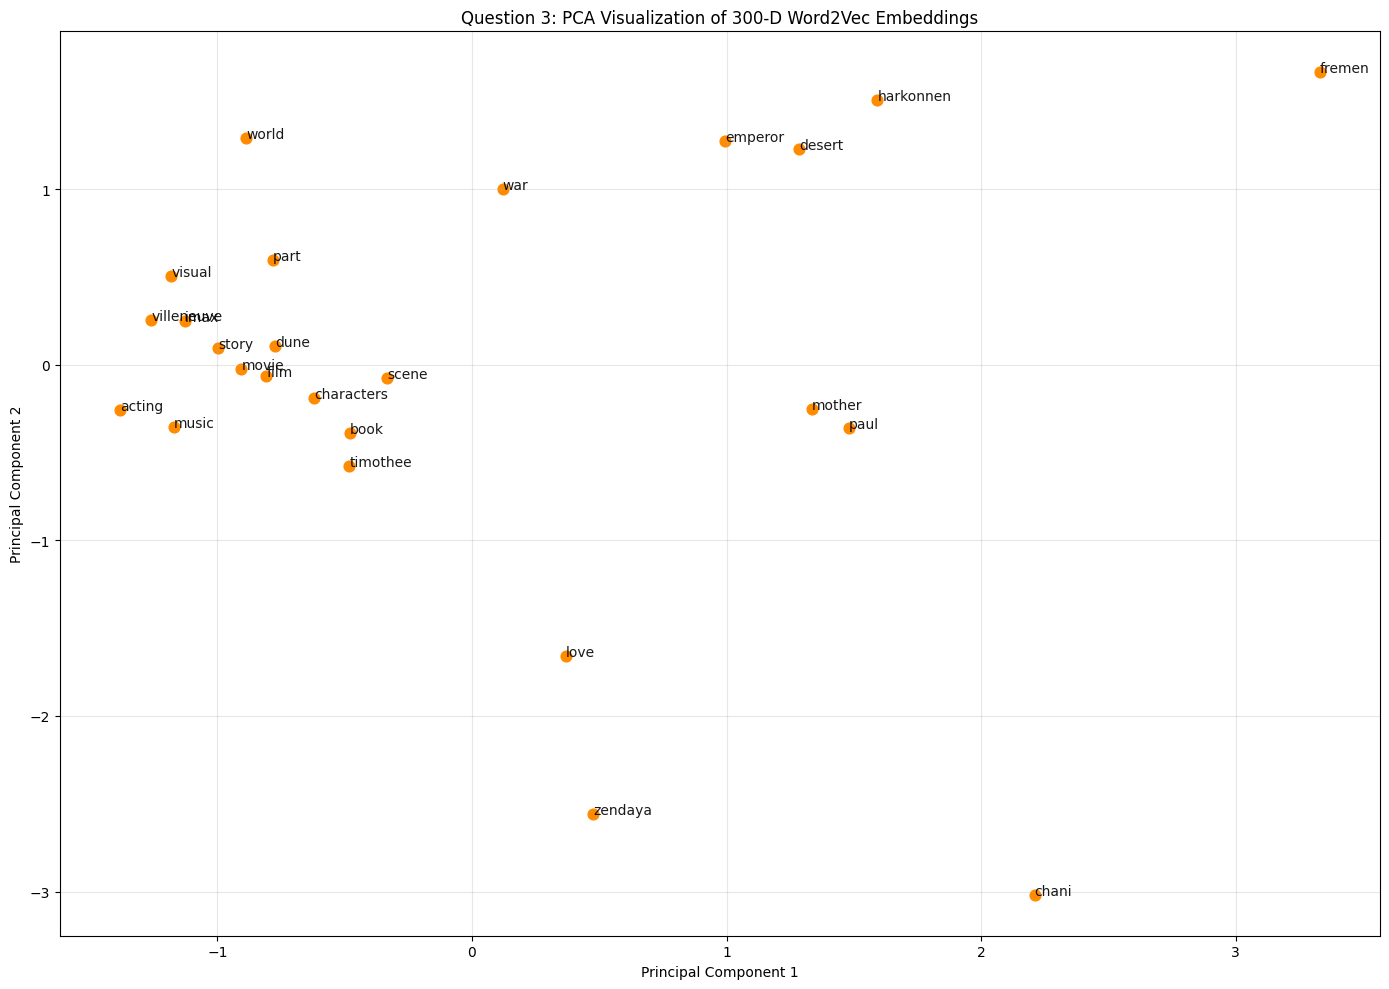

In [14]:
import os
import subprocess
import sys
from collections import Counter
from pathlib import Path

try:
    import pandas as pd
except ModuleNotFoundError:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "pandas"])
    import pandas as pd

MPL_CONFIG_DIR = Path("/tmp/mpl_config")
XDG_CACHE_DIR = Path("/tmp/xdg_cache")
MPL_CONFIG_DIR.mkdir(parents=True, exist_ok=True)
XDG_CACHE_DIR.mkdir(parents=True, exist_ok=True)
os.environ.setdefault("MPLCONFIGDIR", str(MPL_CONFIG_DIR))
os.environ.setdefault("XDG_CACHE_HOME", str(XDG_CACHE_DIR))

try:
    import matplotlib
    matplotlib.use("Agg")
    import matplotlib.pyplot as plt
except ModuleNotFoundError:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "matplotlib"])
    import matplotlib
    matplotlib.use("Agg")
    import matplotlib.pyplot as plt

try:
    import numpy as np
except ModuleNotFoundError:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "numpy"])
    import numpy as np

try:
    from gensim.models import Word2Vec
except ModuleNotFoundError:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "gensim"])
    from gensim.models import Word2Vec

try:
    from sklearn.decomposition import PCA
except ModuleNotFoundError:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "scikit-learn"])
    from sklearn.decomposition import PCA

try:
    from IPython.display import display
except ImportError:
    def display(obj):
        print(obj)

DATA_PATH = Path("q1_imdb_reviews_raw.csv")
TEXT_COLUMN = "text_step4_lowercase"
VECTOR_SIZE = 300
WINDOW_SIZE = 5
MIN_COUNT = 2
EPOCHS = 20
RANDOM_SEED = 42
PLOT_WORD_COUNT = 25
SIMILARITY_PAIRS = [
    ("movie", "film"),
    ("good", "great"),
    ("paul", "chani"),
    ("story", "book"),
    ("visual", "music"),
    ("villeneuve", "director"),
]
PREFERRED_PLOT_WORDS = [
    "dune", "movie", "film", "story", "paul", "chani", "fremen", "harkonnen", "villeneuve", "book",
    "characters", "acting", "visual", "music", "desert", "war", "love", "mother", "emperor", "scene",
    "world", "part", "zendaya", "timothee", "imax", "prophecy", "action", "ending", "sound", "director"
]


reviews_df = pd.read_csv(DATA_PATH).copy()
required_columns = {TEXT_COLUMN}
missing_columns = required_columns.difference(reviews_df.columns)
if missing_columns:
    raise ValueError(f"Missing required columns: {sorted(missing_columns)}")

reviews_df[TEXT_COLUMN] = reviews_df[TEXT_COLUMN].fillna("").astype(str)
sentences = [text.split() for text in reviews_df[TEXT_COLUMN] if text.strip()]
if not sentences:
    raise ValueError("No training sentences are available for Question 3.")

token_counter = Counter()
for sentence in sentences:
    token_counter.update(sentence)

embedding_model = Word2Vec(
    sentences=sentences,
    vector_size=VECTOR_SIZE,
    window=WINDOW_SIZE,
    min_count=MIN_COUNT,
    workers=1,
    sg=1,
    epochs=EPOCHS,
    seed=RANDOM_SEED,
)

vocabulary_words = set(embedding_model.wv.index_to_key)
plot_words = [word for word in PREFERRED_PLOT_WORDS if word in vocabulary_words]
if len(plot_words) < 20:
    for word, _ in token_counter.most_common():
        if word in vocabulary_words and word.isalpha() and len(word) >= 4 and word not in plot_words:
            plot_words.append(word)
        if len(plot_words) >= PLOT_WORD_COUNT:
            break
plot_words = plot_words[:PLOT_WORD_COUNT]

if len(plot_words) < 20:
    raise ValueError("Need at least 20 words for the embedding plot, but fewer were available.")

plot_vectors = np.array([embedding_model.wv[word] for word in plot_words])
pca = PCA(n_components=2, random_state=RANDOM_SEED)
plot_coordinates = pca.fit_transform(plot_vectors)

embedding_plot_df = pd.DataFrame({
    "word": plot_words,
    "x": plot_coordinates[:, 0],
    "y": plot_coordinates[:, 1],
})

similarity_rows = []
for word_a, word_b in SIMILARITY_PAIRS:
    if word_a in vocabulary_words and word_b in vocabulary_words:
        score = float(embedding_model.wv.similarity(word_a, word_b))
        similarity_rows.append({
            "word_a": word_a,
            "word_b": word_b,
            "cosine_similarity": round(score, 6),
        })

if not similarity_rows:
    raise ValueError("No similarity pairs were found in the trained vocabulary.")

word_similarity_df = pd.DataFrame(similarity_rows).sort_values(
    ["cosine_similarity", "word_a", "word_b"],
    ascending=[False, True, True],
).reset_index(drop=True)

nearest_neighbor_rows = []
for anchor_word in ["dune", "movie", "paul"]:
    if anchor_word in vocabulary_words:
        for neighbor_word, similarity_score in embedding_model.wv.most_similar(anchor_word, topn=5):
            nearest_neighbor_rows.append({
                "anchor_word": anchor_word,
                "neighbor_word": neighbor_word,
                "similarity": round(float(similarity_score), 6),
            })
nearest_neighbors_df = pd.DataFrame(nearest_neighbor_rows)

plot_ready = embedding_plot_df.shape[0] >= 20 and embedding_plot_df.shape[1] == 3
similarity_range_ok = bool(word_similarity_df["cosine_similarity"].between(-1, 1).all())

print(f"Loaded {len(sentences)} training documents from {DATA_PATH} using {TEXT_COLUMN}.")
print(f"Word2Vec configuration: vector_size={VECTOR_SIZE}, window={WINDOW_SIZE}, min_count={MIN_COUNT}, epochs={EPOCHS}, sg=1")
print(f"Vocabulary size: {len(vocabulary_words)}")
print(f"Words selected for PCA plot: {len(plot_words)}")
print()
print("Validation checks")
print("Embedding dimensionality is 300:", embedding_model.vector_size == 300)
print("PCA plot has at least 20 words:", plot_ready)
print("Cosine similarity scores are within [-1, 1]:", similarity_range_ok)
print()
print("Sample cosine similarity pairs")
display(word_similarity_df)
print()
print("Nearest neighbors for a few anchor words")
display(nearest_neighbors_df)

plt.figure(figsize=(14, 10))
plt.scatter(embedding_plot_df["x"], embedding_plot_df["y"], color="darkorange", s=60)
for _, row in embedding_plot_df.iterrows():
    plt.annotate(row["word"], (row["x"], row["y"]), fontsize=10, alpha=0.9)
plt.title("Question 3: PCA Visualization of 300-D Word2Vec Embeddings")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.grid(alpha=0.3)
plt.tight_layout()
display(plt.gcf())
plt.close()


## Question 4 (20 Points)

**Create your own training and evaluation dataset for an NLP task.**

 **You don't need to write program for this question!**

 For example, if you collected a movie review or a product review data, then you can do the following steps:

*   Read each review (abstract or tweet) you collected in detail, and annotate each review with a sentiment (positive, negative, or neutral).

*   Save the annotated dataset into a csv file with three columns (first column: document_id, clean_text, sentiment), upload the csv file to GitHub and submit the file link blew.

*   This datset will be used for assignment four: sentiment analysis and text classification.




1.   Which NLP Task you would like perform on your selected dataset
(NER, Summarization, Sentiment Analysis, Text classficication)
2.  Explain your labeling Schema you have used and mention those labels

3.  You can take AI assistance for labeling the data only.



In [4]:
https://github.com/minasaeday14/INFO-5731-spring-2026/blob/main/q4_imdb_sentiment_dataset.csv

# Mandatory Question (5 Points)

Provide your thoughts on the assignment by filling this survey link. What did you find challenging, and what aspects did you enjoy? Your opinion on the provided time to complete the assignment.


I found the n-gram, TF-IDF, and word embedding parts the most challenging because they needed more careful coding and checking. I enjoyed working with the movie review dataset and seeing how the text changed after preprocessing and analysis. The time given was mostly fair, but some parts took longer than expected, especially when training models and organizing the outputs clearly